In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index --Extension"


In [2]:

# Open and read the JSON file
with open("best_models_grid_search_3d.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [3]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
join_result_path = "../result/libspatialindex/HDD/4K/{name}/join/"
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix_point = {'bmtree':'_bits_32_depth_10_sample_80000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_80000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_10_sample_10000_gamma_0.8_learning_rate_0.01_rl_method_0',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}


data_names = ["us_100000000", "tiger_blocks_8180866", "tiger_linearwater_5668549", "tiger_roads_17813006"]
display_data_names = ["Point", "Block", "Linearwater", "Road"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"

build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'kdtree', 'kdtree_greedy', 'waffle', 'qdtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'qdtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'lisa', 'qdtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
# display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Waffle', 'Qd-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree', 'Kd-tree', 'GKd-tree', 'LISA', 'Qd-tree']

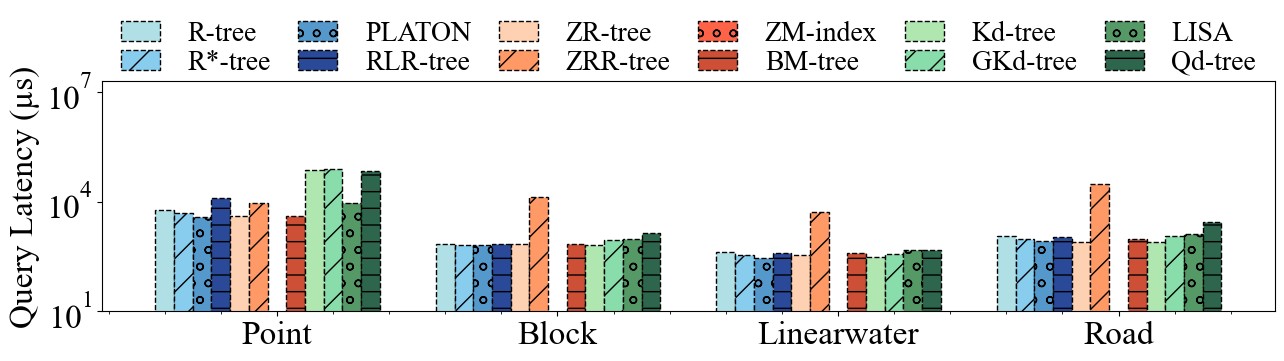

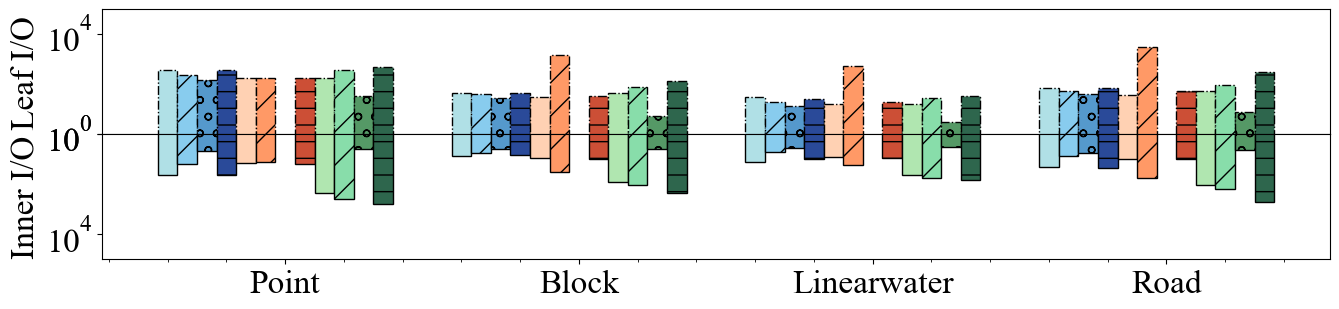

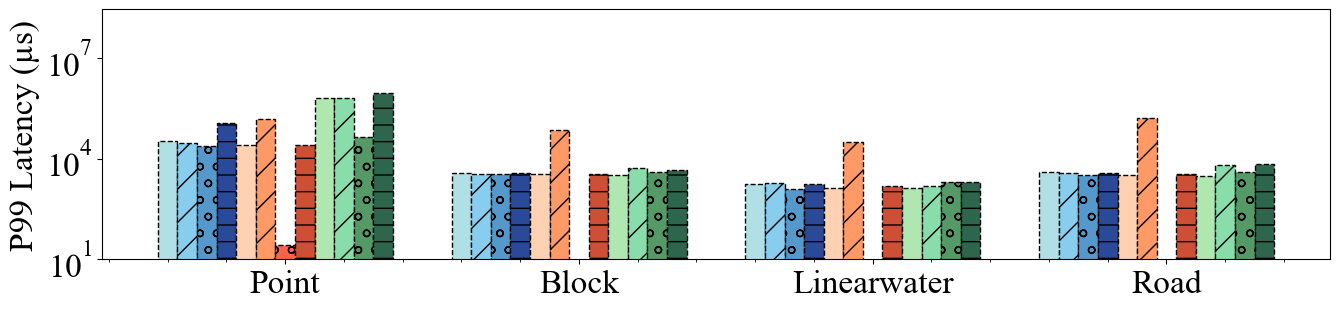

In [4]:
real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"


result = []
IO = []

P99 = []
P50 = []

query_result_num = []

QueryPercentage = {}

for baseline in baselines:

    suffix = baseline_suffix[baseline]
    
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        if data_name == "us_100000000":
            suffix = baseline_suffix_point[baseline]
        else:
            suffix = baseline_suffix[baseline]
        
        if data_name.startswith("data"):
            range_name = synthetic_default_range_name_pattern
        else:
            range_name = real_default_range_name_pattern.format(data_name=data_name)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)

        tree_property = parse_rtree_properties(res)

        # if baseline == 'zm':
        #     dataset_results.append(0)
        # else:
        # if baseline == 'zm' and data_name == 'tiger_blocks_8180866':
        #     print(tree_property.QueryMean) 
        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo)/1000)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
    # if baseline == 'platon':
    #     print("platon", dataset_IO)
    #     print("platon", dataset_P99)
    # if baseline == 'rankspace_zorder':
    #     print("rankspace_zorder", dataset_IO) 
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num) 
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

# # print(IO)
# for item in result:
#     print(item)


# plot_hist(display_data_names, display_baselines, query_result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/range_query_result_num.pdf", "../figs/exp/range_query_result_num.png"])

# plot_hist(data_names, baselines, result)

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_object.pdf", "../figs/exp_sigmod/range_query_time_object.png"], bottom=1e1, top=2*1e7, legend_location="top")

# plot_hist(display_data_names, display_baselines, IO, y_label="I/O", output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"])

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], legend_location="right")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO_object.pdf", "../figs/exp_sigmod/range_query_IO_object.png"], legend_labels=["Leaf I/O", "Inner I/O"],
                bottom1=1, top1=100000, bottom2=1, top2=100000, legend_location="top")

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99_object.pdf", "../figs/exp_sigmod/range_query_P99_object.png"], bottom=1e1, top=3*1e8, legend_location="top")

[[30, 4], [0, 0], [0, 0], [0, 0]]
../result/libspatialindex/HDD/4K/bmtree/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_10000.txt
../result/libspatialindex/HDD/4K/bmtree/build/tiger_blocks_8180866_tiger_blocks_8180866_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_10000.txt
../result/libspatialindex/HDD/4K/bmtree/build/tiger_linearwater_5668549_tiger_linearwater_5668549_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_10000.txt
../result/libspatialindex/HDD/4K/bmtree/build/tiger_roads_17813006_tiger_roads_17813006_range_1000_2_uniform_1_0.001x0.001_bits_32_depth_10_sample_10000.txt
../result/libspatialindex/HDD/4K/kdtree_greedy/build/us_100000000_us_100000000_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/kdtree_greedy/build/tiger_blocks_8180866_tiger_blocks_8180866_range_1000_2_uniform_1_0.001x0.001.txt
../result/libspatialindex/HDD/4K/kdtree_greedy/build/tiger_linearwater_5668549_tiger_linearw

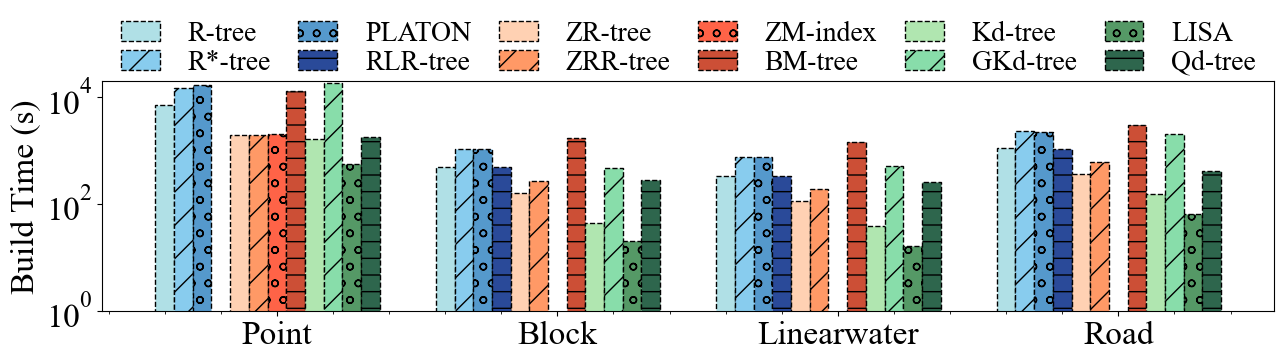

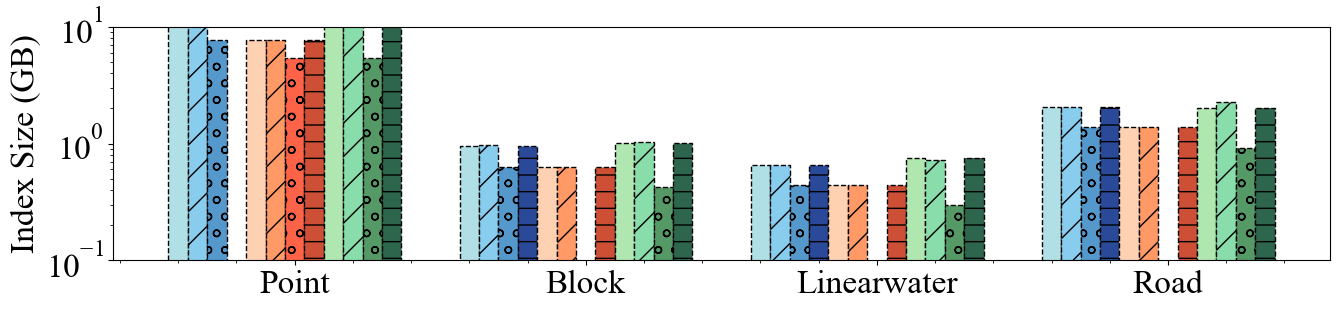

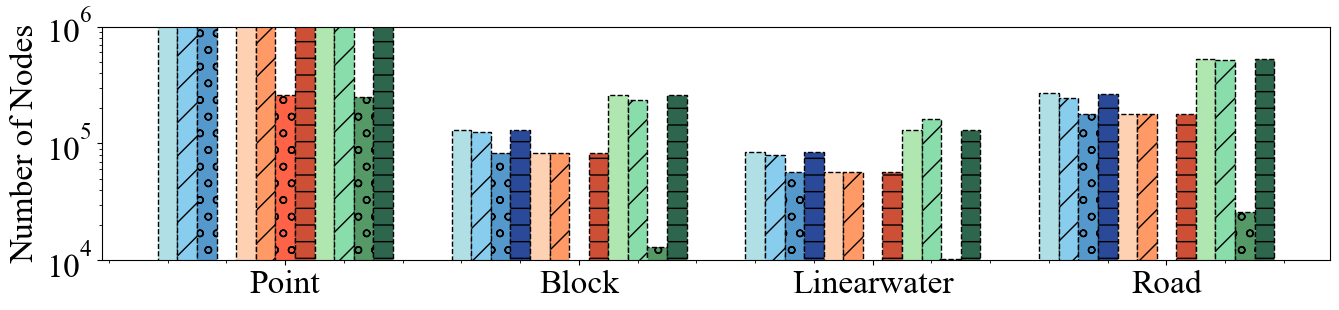

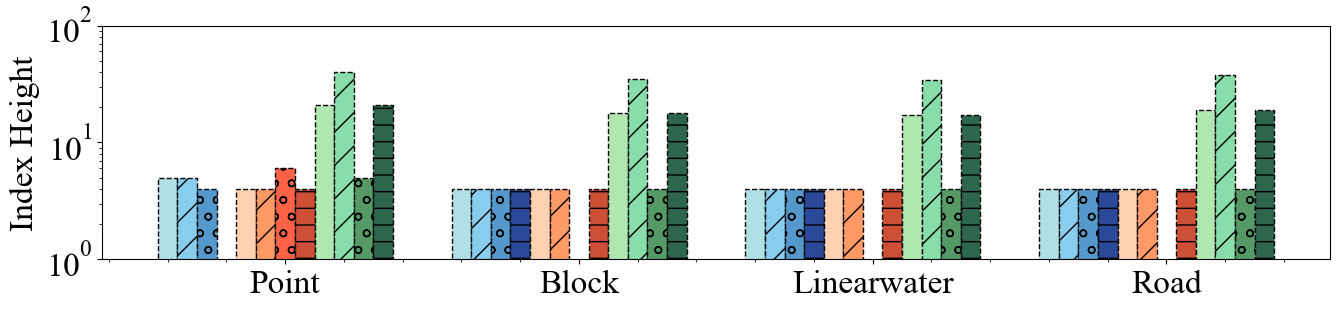

In [5]:
result = []
utilization_result = []
splits_result = []
adjustments_result = []
index_size = []
node_number = []
tree_height = []
build = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_utilization_results = []
    dataset_splits_results = []
    dataset_adjustments_results = []
    dataset_index_size = []
    dataset_node_number = []
    dataset_tree_height = []
    dataset_build = []
    
    for i, data_name in enumerate(data_names):
        
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline), build_result_name)
        
        tree_property = parse_rtree_properties(res)
        
        # dataset_results.append({
        #     'ElapsedTime': tree_property.ElapsedTime,
        #     'ElapsedBuildTime': tree_property.ElapsedBuildTime,
        #     'ElapsedLearnTime': tree_property.ElapsedLearnTime
        # })

        dataset_build.append([int(tree_property.ElapsedLearnTime / 1e9 / 60) , int(tree_property.ElapsedBuildTime / 1e9 / 60)])
        # print(tree_property.ElapsedTime, tree_property.ElapsedLearnTime)
        dataset_results.append(float(tree_property.ElapsedTime / 1e9))
        dataset_utilization_results.append(tree_property.Utilization)
        dataset_splits_results.append(tree_property.Splits)
        dataset_adjustments_results.append(tree_property.Adjustments / 1e6)
        dataset_index_size.append((tree_property.TreeDatSize + tree_property.TreeIdxSize) / (1024 * 1024 * 1024))
        dataset_node_number.append(tree_property.NumberOfNodes)
        dataset_tree_height.append(tree_property.TreeHeight)
        # print(baseline, data_name, tree_property.Utilization)
        if baseline == 'kdtree_greedy' or baseline == 'bmtree':
            print(res)

    if baseline == 'zm':
        print(dataset_build)

    result.append(dataset_results) 
    utilization_result.append(dataset_utilization_results) 
    splits_result.append(dataset_splits_results) 
    adjustments_result.append(dataset_adjustments_results) 
    # print(baseline, dataset_adjustments_results)
    index_size.append(dataset_index_size)
    node_number.append(dataset_node_number)
    tree_height.append(dataset_tree_height)
    build.append(dataset_build)

plot_hist(display_data_names, display_baselines, result, y_label="Build Time (s)", is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/build_object.pdf", "../figs/exp_sigmod/build_object.png"],bottom=1e0, top=2*1e4, legend_location="top")

plot_hist(display_data_names, display_baselines, index_size, y_label="Index Size (GB)", is_legend=False, is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/index_size_object.pdf", "../figs/exp_sigmod/index_size_object.png"],bottom=0.1, top=10, legend_location="top")

plot_hist(display_data_names, display_baselines, node_number, y_label="Number of Nodes", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/node_number_object.pdf", "../figs/exp_sigmod/node_number_object.png"],bottom=1e4, top=1e6, legend_location="top")

plot_hist(display_data_names, display_baselines, tree_height, y_label="Index Height", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/tree_height_object.pdf", "../figs/exp_sigmod/tree_height_object.png"],bottom=1, top=100, legend_location="top")


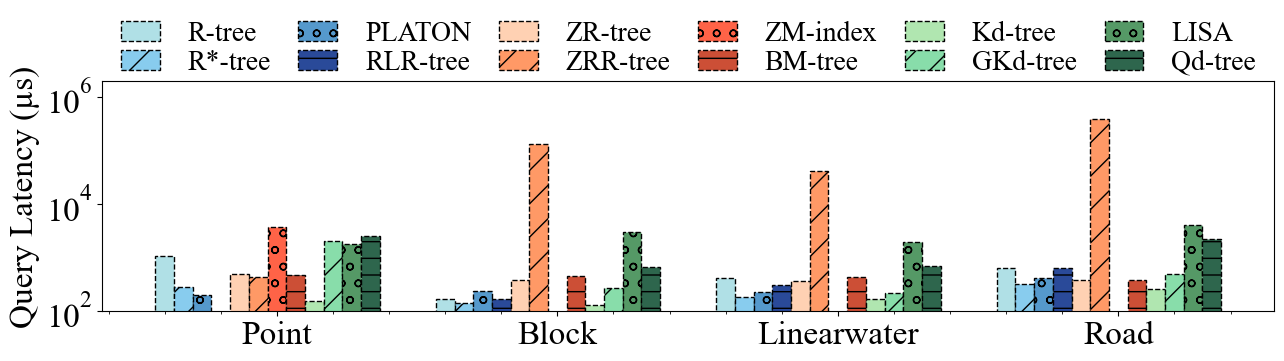

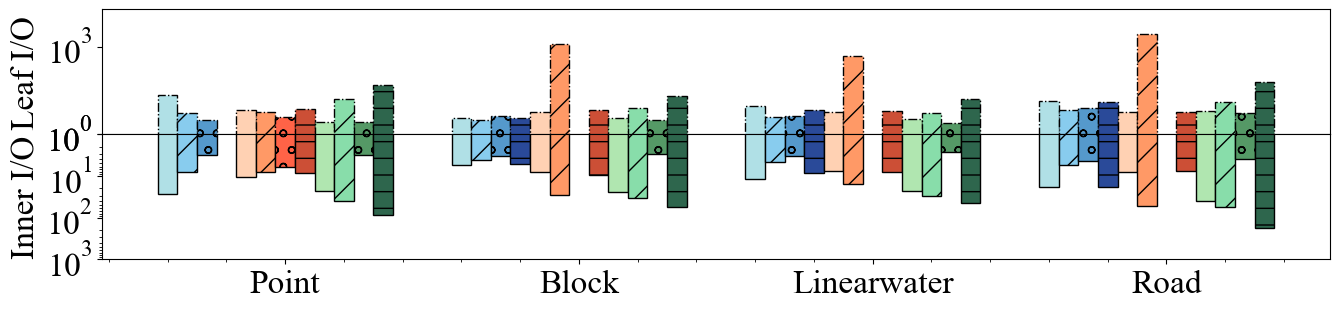

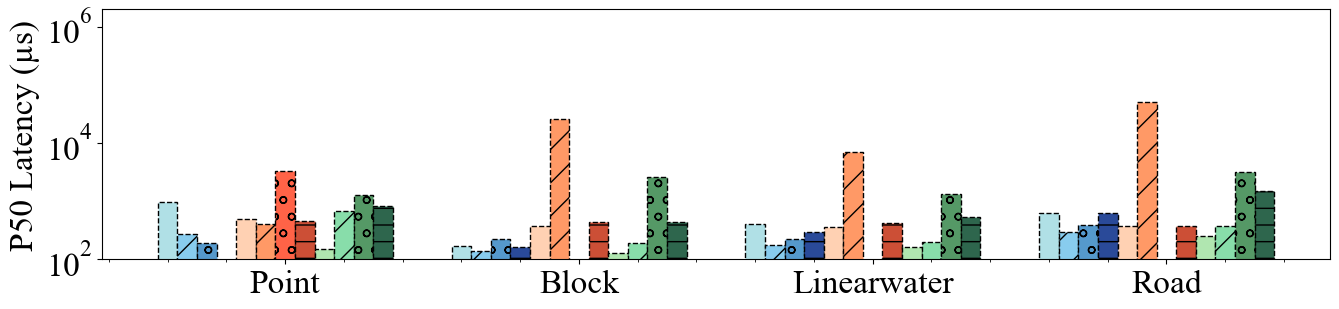

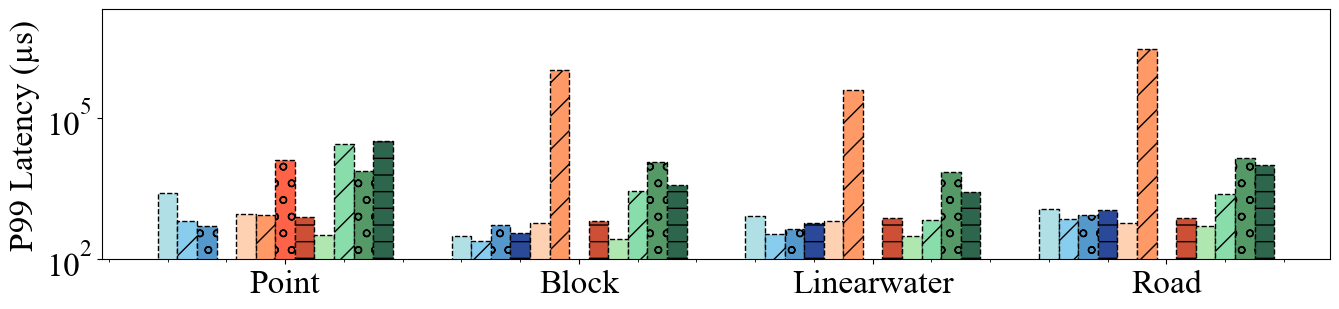

In [6]:
# 1 
k=25
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']


real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"

# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']


result = []
result_num = []
IO = []

P99 = []
P50 = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for data_name in data_names:

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            knn_name = synthetic_knn_name
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            knn_name = real_knn_name.format(data_name=data_name)
        
        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # print(tree_property.QueryNum, data_name, baseline)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage
 
# for item in result:
#     print(item)

# print(IO)
# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time_object.pdf", "../figs/exp_sigmod/knn_query_time_object.png"], bottom=1e2, top=2*1e6, legend_location="top")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_IO_object.pdf", "../figs/exp_sigmod/knn_query_IO_object.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=2*1e4, bottom2=1, top2=1e3)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P50_object.pdf", "../figs/exp_sigmod/knn_query_P50_object.png"], bottom=1e2, top=2*1e6)

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P99_object.pdf", "../figs/exp_sigmod/knn_query_P99_object.png"], bottom=1e2, top=2*1e7)